<a href="https://colab.research.google.com/github/marleenroomet/digital-pcr/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Digital PCR by Aditi Shinkhede & Marleen Roomet (Group 09)**



# **Project card**

**The paper:** Vogelstein, B. & Kinzler, K. W. (1999). Digital PCR. Proceedings of the National Academy of Sciences, 96(16), 9236–9241

**The data object:** The main data object we use is the fluorescence measurement from each well together with the RED/GREEN fluorescence ratio used to classify wells as normal, mixed or mutant.

**The random variable chosen:** The number of DNA template molecules present in each well.

**What the paper does:** The paper distributes diluted DNA into individual wells and amplifies the DNA. MB-RED is used to detect PCR products, while MB-GREEN preferentially detects wild type DNA. The RED/GREEN ratio is then used to identify wells containing mutant DNA.

**The generative model proposed:** DNA molecules are randomly distributed between wells according to a Poisson distribution.

**Parameters and assumptions:** The parameters include the mean DNA molecules per well (lambda = 0.45) and the mutant fraction (5%). We use fluorescence distributions provided by the stool sample experiment: approximately 47 000 ± 18 000 SFU for PCR positive wells and 2 600 ± 1 500 SFU for PCR negative wells. A PCR threshold of 10 000 SFU is used as their threshold. RED/GREEN thresholds of 1.5 and 3.0 are used to identify mixed and strongly mutant wells.

We assume that DNA molecules are randomly distributed between wells, that mutant status is independently assigned to DNA molecules and that measurement noise can be represented by normal distributions.

**The forward simulation:** We simulate 384 well plates. For each well, the model randomly generates the number of DNA templates, the number of mutant molecules, PCR fluorescence and RED/GREEN ratio. The simulated measurements are then classified using the PCR and RED/GREEN thresholds. We visualize the results with a scatterplot.

**The parameterization:** Lambda is chosen so that the expected fraction of wells containing DNA is close to the observed fraction of PCR positive stool wells (102/288 ≈ 35%) given the exponential distribution function formula F(t) = 1 − e^(−λt). The mutant fraction of 5% is a midpoint of the expected 1-10%. The fluorescence parameters are based on the reported positive and negative SFU distributions.

**What the model adds to the paper:** The model provides a way to explore how random DNA partitioning and measurement noise can produce variation between digital PCR experiments. By repeatedly simulating the experiment (for example 2000 times), we can estimate the expected range of mutant positive results and the probability of obtaining at least five mutant positive wells under our assumptions.

**Model limitations:** The model simplifies several aspects of the experimental system. The relationship between mutant fraction and RED/GREEN ratio is assumed to be linear, although this relationship is not established by the paper as a general quantitative model. The fluorescence distributions are also simplified using normal distributions. The model does not explicitly represent PCR amplification, probe binding, sequencing or polymerase errors. Therefore, the simulation should be interpreted as a simplified model of the experiment rather than a complete model of the biological process.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Parameters


The parameters are derived from the stool experiment, but the observed stool results are not hard coded. The goal is for repeated 384 well simulations to produce results in a similar range, not to reproduce one particular plate exactly.

In [43]:
# DNA molecules
lambda_template = 0.45
mutant_fraction = 0.05

# PCR fluorescence (SFU), derived from the stool experiment
positive_signal_mean = 47_000
positive_signal_sd = 18_000
negative_signal_mean = 2_600
negative_signal_sd = 1_500

# PCR detection threshold
pcr_threshold = 10_000

# RED/GREEN measurement noise
ratio_noise = 0.20

# Ratio thresholds
ratio_mixed_threshold = 1.5
ratio_mutant_threshold = 3.0

# Number of wells and random number generator
n_wells = 384
rng = np.random.default_rng(seed=42)


## 2. Simulate one plate

Unlike a one-to-one stool reproduction, our code does not force a specific number of positive or mutant wells. All of our outcomes arise from the model.

In [44]:
def simulate_plate(n_wells, lambda_template, mutant_fraction, rng):
    # DNA molecules per well
    template_count = rng.poisson(lambda_template, size=n_wells)

    # Mutant and WT molecule counts
    mutant_count = rng.binomial(template_count, mutant_fraction)
    wt_count = template_count - mutant_count

    # Molecule count cannot be 0
    true_pcr_positive = template_count > 0

    # Fraction of molecules that are mutant in each well
    mutant_share = np.divide(
        mutant_count,
        template_count,
        out=np.zeros(n_wells),
        where=template_count > 0)

    # PCR fluorescence
    pcr_signal_mean = np.where(
        true_pcr_positive,
        positive_signal_mean,
        negative_signal_mean)

    pcr_signal_sd = np.where(
        true_pcr_positive,
        positive_signal_sd,
        negative_signal_sd)

    pcr_signal = rng.normal(pcr_signal_mean, pcr_signal_sd)
    pcr_signal = np.clip(pcr_signal, 0, None)

    # RED/GREEN ratio
    # Formula assumes ratio is linear
    # WT ratio mean was about 1.0
    # Mixed ratio mean was 2.1 (this formula gives us 2.2)
    # Pure mutant ratio mean was about 3.4
    ratio_mean = 1.0 + 2.4 * mutant_share
    red_green_ratio = np.full(n_wells, np.nan)

    red_green_ratio[true_pcr_positive] = rng.normal(
        ratio_mean[true_pcr_positive],
        ratio_noise)

    red_green_ratio = np.clip(red_green_ratio, 0.1, None)

    # Detected PCR products
    detected_pcr_positive = pcr_signal > pcr_threshold

    # Strong mutant results
    detected_mutant_positive = (detected_pcr_positive
        & (red_green_ratio > ratio_mutant_threshold))

    # Mixed results
    mixed_well = (detected_pcr_positive
        & (red_green_ratio > ratio_mixed_threshold)
        & (red_green_ratio <= ratio_mutant_threshold))

    # Storing info on each well individually
    return pd.DataFrame({
        'template_count': template_count,
        'mutant_count': mutant_count,
        'wt_count': wt_count,
        'true_pcr_positive': true_pcr_positive,
        'mutant_share': mutant_share,
        'pcr_signal_SFU': pcr_signal,
        'red_green_ratio': red_green_ratio,
        'detected_pcr_positive': detected_pcr_positive,
        'detected_mutant_positive': detected_mutant_positive,
        'mixed_well': mixed_well})


# 3. Simulation results

In [45]:
plate = simulate_plate(
    n_wells=n_wells,
    lambda_template=lambda_template,
    mutant_fraction=mutant_fraction,
    rng=rng)

print('ONE SIMULATED 384 WELL PLATE')
print(f"PCR positive wells: {plate['detected_pcr_positive'].sum()}")
print(f"Mutant wells: {plate['detected_mutant_positive'].sum()}")
print(f"Mixed wells: {plate['mixed_well'].sum()}")
print(f"Mean positive fluorescence: {plate.loc[plate['true_pcr_positive'], 'pcr_signal_SFU'].mean():,.0f} SFU")
print(f"Mean negative fluorescence: {plate.loc[~plate['true_pcr_positive'], 'pcr_signal_SFU'].mean():,.0f} SFU")


ONE SIMULATED 384 WELL PLATE
PCR positive wells: 127
Mutant wells: 8
Mixed wells: 4
Mean positive fluorescence: 46,721 SFU
Mean negative fluorescence: 2,564 SFU


## 4. Visualizing previously received results


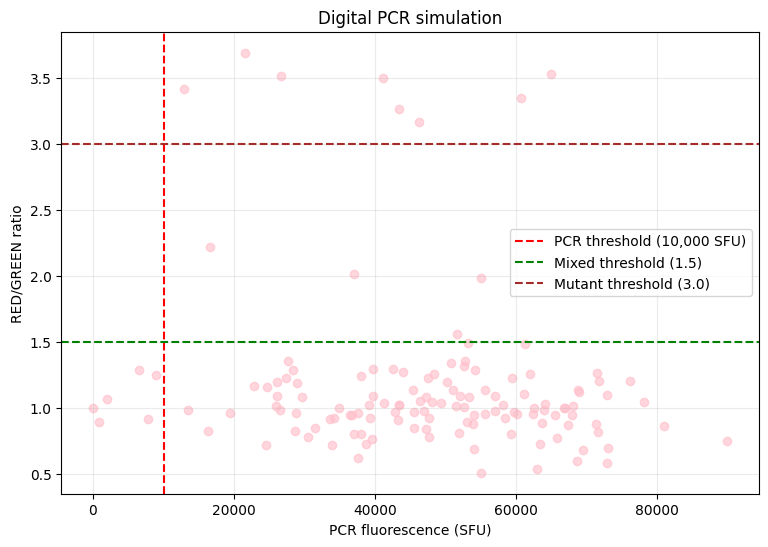

In [46]:
plt.figure(figsize=(9, 6))

plt.scatter(
    plate['pcr_signal_SFU'],
    plate['red_green_ratio'],
    alpha=0.65,
    color="pink")

plt.axvline(
    pcr_threshold,
    linestyle='--',
    label='PCR threshold (10,000 SFU)',
    color="red")

plt.axhline(
    ratio_mixed_threshold,
    linestyle='--',
    label='Mixed threshold (1.5)',
    color="green")

plt.axhline(
    ratio_mutant_threshold,
    linestyle='--',
    label='Mutant threshold (3.0)',
    color="brown")

plt.xlabel('PCR fluorescence (SFU)')
plt.ylabel('RED/GREEN ratio')
plt.title('Digital PCR simulation')
plt.legend()
plt.grid(alpha=0.25)
plt.show()


# 5. Exploring uncertainty

To do so, we conduct 2000 virtual experiments, visualize it with a histogram and provide probabilities.

In [47]:
# Number of virtual experiments
n_experiments = 2000

# Store the number of mutant wells from each experiment
mutant_results = []

for i in range(n_experiments):

    # Simulating our one 384 well plate again
    plate = simulate_plate(
        n_wells=n_wells,
        lambda_template=lambda_template,
        mutant_fraction=mutant_fraction,
        rng=rng)

    # Counting mutant wells
    n_mutants = plate["detected_mutant_positive"].sum()

    # Save the result
    mutant_results.append(n_mutants)

# Convert to numpy array
mutant_results = np.array(mutant_results)

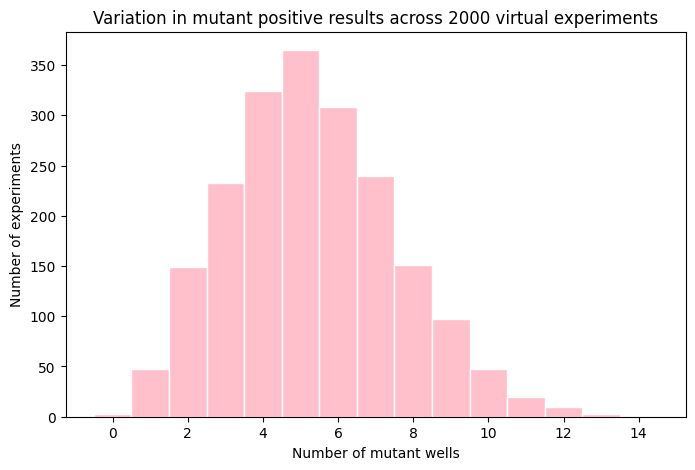

In [48]:
plt.figure(figsize=(8, 5))

plt.hist(
    mutant_results,
    bins=np.arange(mutant_results.min() - 0.5,
    mutant_results.max() + 1.5, 1),
    edgecolor = "white",
    color="pink")

plt.xlabel("Number of mutant wells")
plt.ylabel("Number of experiments")
plt.title("Variation in mutant positive results across 2000 virtual experiments")
plt.show()

In [49]:
lower_95 = np.percentile(mutant_results, 2.5)
upper_95 = np.percentile(mutant_results, 97.5)

prob_atleast_5 = np.mean(mutant_results >= 5)

print(f"95% interval: {lower_95:.0f} to {upper_95:.0f} mutant results")
print(f"Probability of ≥5 mutant results: {prob_atleast_5:.3f}")

95% interval: 1 to 10 mutant results
Probability of ≥5 mutant results: 0.622
